In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#data analysis
data=pd.read_csv("C:/Users/allad/Downloads/store_sales.csv")
data.head()
print('Missing values\n',data.isnull().sum())
print('Duplicate values\n',data.duplicated().sum())
print('Rows and Columns:',data.shape)
data['date'] = pd.to_datetime(data['date'])
print(data.info())
data = data.sort_values(['store','date'])
data.describe()

Missing values
 date       0
store      0
sales      0
promo      0
holiday    0
dtype: int64
Duplicate values
 0
Rows and Columns: (7300, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7300 non-null   datetime64[ns]
 1   store    7300 non-null   int64         
 2   sales    7300 non-null   float64       
 3   promo    7300 non-null   int64         
 4   holiday  7300 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 285.3 KB
None


,date,store,sales,promo,holiday
count,7300,7300.000000,7300.000000,7300.000000,7300.000000
mean,2022-12-31 12:00:00,5.500000,228.434571,0.202192,0.104110
min,2022-01-01 00:00:00,1.000000,160.710000,0.000000,0.000000
25%,2022-07-02 00:00:00,3.000000,209.217500,0.000000,0.000000
50%,2022-12-31 12:00:00,5.500000,226.795000,0.000000,0.000000
75%,2023-07-02 00:00:00,8.000000,245.590000,0.000000,0.000000
max,2023-12-31 00:00:00,10.000000,340.730000,1.000000,1.000000
std,NaN,2.872478,26.625636,0.401662,0.305424


In [4]:
#creating date features
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
data['weekday'] = data['date'].dt.weekday
#creating lag features
data['lag_1'] = data.groupby('store')['sales'].shift(1)
data['lag_7'] = data.groupby('store')['sales'].shift(7)
print(data[['store','date','sales','lag_1','lag_7']].head(15))
data.dropna(inplace=True)
#after removing missing values in lag features
data[['store','date','sales','lag_1','lag_7']].head(15)
data.columns

    store       date   sales   lag_1   lag_7
0       1 2022-01-01  184.78     NaN     NaN
1       1 2022-01-02  192.62  184.78     NaN
2       1 2022-01-03  212.68  192.62     NaN
3       1 2022-01-04  249.58  212.68     NaN
4       1 2022-01-05  223.50  249.58     NaN
5       1 2022-01-06  221.79  223.50     NaN
6       1 2022-01-07  200.43  221.79     NaN
7       1 2022-01-08  213.47  200.43  184.78
8       1 2022-01-09  222.44  213.47  192.62
9       1 2022-01-10  203.10  222.44  212.68
10      1 2022-01-11  218.78  203.10  249.58
11      1 2022-01-12  266.23  218.78  223.50
12      1 2022-01-13  204.68  266.23  221.79
13      1 2022-01-14  218.31  204.68  200.43
14      1 2022-01-15  183.36  218.31  213.47


Index(['date', 'store', 'sales', 'promo', 'holiday', 'year', 'month', 'day',
       'weekday', 'lag_1', 'lag_7'],
      dtype='object')

In [7]:
#X,y features
X=data[[ 'store',  'promo', 'holiday', 'year', 'month', 'day','weekday', 'lag_1', 'lag_7']]
y=data['sales']
#splitting data on time based
split = int(len(data)*0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
#create model
model = RandomForestRegressor(n_estimators=100,random_state=42)
#training model
model.fit(X_train, y_train)
#model prediction
pred = model.predict(X_test)
#evaluation
mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:",rmse)
r2 = r2_score(y_test, pred)
print("R2 Score:", r2)
#actual vs predicted
res=pd.DataFrame({'Actual':y_test,
                 'Predicted':pred})
print(res.head(10))

MAE: 9.782652904564314
RMSE: 11.699426549952133
R2 Score: 0.8323340377568716
      Actual  Predicted
5847  194.87   190.1907
5848  198.22   192.9081
5849  208.34   212.4791
5850  234.61   222.8559
5851  271.32   254.2786
5852  273.22   264.4877
5853  209.36   193.6507
5854  223.23   224.6210
5855  192.49   188.0970
5856  221.87   209.3135


In [11]:
#new data prediction
new_data = pd.DataFrame({
    'store':[3],
    'promo':[1],
    'holiday':[0],
    'year':[2024],
    'month':[1],
    'day':[1],
    'weekday':[0],
    'lag_1':[220],
    'lag_7':[210]
})
print('New data\n',new_data)
predn = model.predict(new_data)
print("Predicted Saleson new data:", predn[0])

New data
    store  promo  holiday  year  month  day  weekday  lag_1  lag_7
0      3      1        0  2024      1    1        0    220    210
Predicted Saleson new data: 241.81710000000007


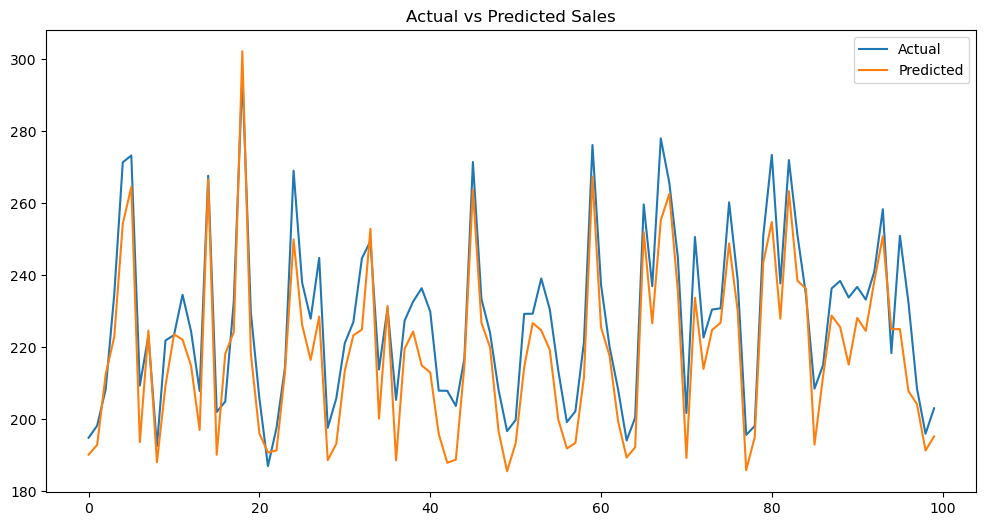

In [9]:
#visulaizations
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(pred[:100], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

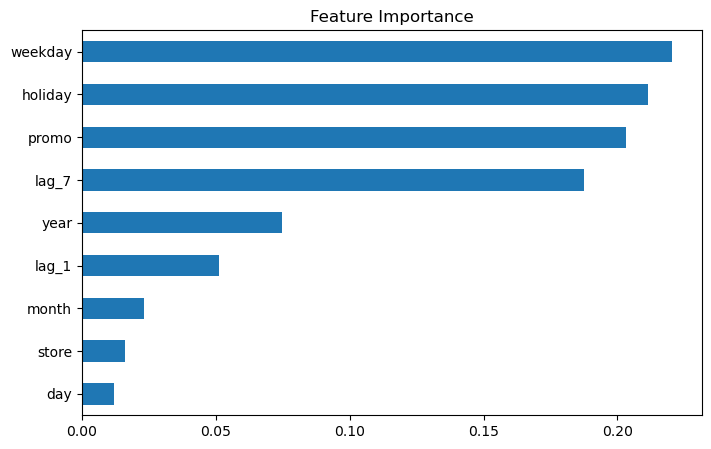

In [10]:
#feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)
importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)
plt.title("Feature Importance")
plt.show()